In [60]:
# Imports
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path
import pandas as pd
import geopandas as gpd
import fiona
import matplotlib.pyplot as plt
import numpy as np

Loading Costs Data (pyCIAM Model)

In [9]:
# Load the zarr file as xarray dataset
zarr_path = Path("./pyCIAM_outputs.zarr")
ds = xr.open_zarr(zarr_path)
ds

<xarray.Dataset> Size: 2GB
Dimensions:       (case: 11, costtype: 6, adm1: 1836, scenario: 5, quantile: 1,
                   year: 96, ssp: 5, iam: 2, seg: 9568)
Coordinates:
  * case          (case) <U12 528B 'noAdaptation' 'protect10' ... 'optimalfixed'
  * costtype      (costtype) <U15 360B 'wetland' ... 'stormPopulation'
  * adm1          (adm1) <U8 59kB 'ABW' 'AGO.11_1' ... 'ZNC.3_1' 'ZNC.4_1'
  * scenario      (scenario) <U17 340B 'SSP126' 'SSP245' ... 'ncc_regional_rise'
  * quantile      (quantile) float64 8B 0.5
  * year          (year) int32 384B 2005 2006 2007 2008 ... 2097 2098 2099 2100
  * ssp           (ssp) <U4 80B 'SSP1' 'SSP2' 'SSP3' 'SSP4' 'SSP5'
  * iam           (iam) <U5 40B 'IIASA' 'OECD'
  * seg           (seg) <U9 344kB 'seg_00001' 'seg_00002' ... 'seg_99019'
Data variables:
    costs         (case, costtype, adm1, scenario, quantile, year, ssp, iam) float32 2GB dask.array<chunksize=(11, 6, 9, 5, 1, 10, 5, 2), meta=np.ndarray>
    optimal_case  (seg, scenario, quantile, ssp, iam) uint8 478kB dask.array<chunksize=(9568, 5, 1, 5, 2), meta=np.ndarray>
Attributes:
    description:                  pyCIAM run with regional rise SLR data mapp...
    planning_period_start_years:  [2005, 2010, 2020, 2030, 2040, 2050, 2060, ...
    updated:                      Thu Feb 12 16:54:07 2026

Load Regional Sea Level Rise (RSLR) Data (BRICK framework)

In [35]:
# SSP1-2.6
ssp126_ds = xr.open_dataset("./regional_rise/slr_ssp126.nc")
ssp126_slr = (ssp126_ds["slr"].sel(time=2100) - ssp126_ds["slr"].sel(time=2015)) / 10
# SSP2-4.5
ssp245_ds = xr.open_dataset("./regional_rise/slr_ssp245.nc")
ssp245_slr = (ssp245_ds["slr"].sel(time=2100) - ssp245_ds["slr"].sel(time=2015)) / 10
# SSP3-7.0
ssp370_ds = xr.open_dataset("./regional_rise/slr_ssp370.nc")
ssp370_slr = (ssp370_ds["slr"].sel(time=2100) - ssp370_ds["slr"].sel(time=2015)) / 10
# SSP5-8.5
ssp585_ds = xr.open_dataset("./regional_rise/slr_ssp585.nc")
ssp585_slr = (ssp585_ds["slr"].sel(time=2100) - ssp585_ds["slr"].sel(time=2015)) / 10

SSP2-4.5 Sea Level Rise Weighted Global Mean

In [36]:
# Latitude weights
weights_ssp245 = np.cos(np.deg2rad(ssp245_slr.lat))
# Normalize weights
weights_ssp245 = weights_ssp245 / weights_ssp245.mean()
# Global mean sea level rise
global_mean_ssp245 = ssp245_slr.weighted(weights_ssp245).mean(("lat", "lon"))
print(global_mean_ssp245.values)

0.5116619160642445


SSP2-4.5 RSRL Plotted

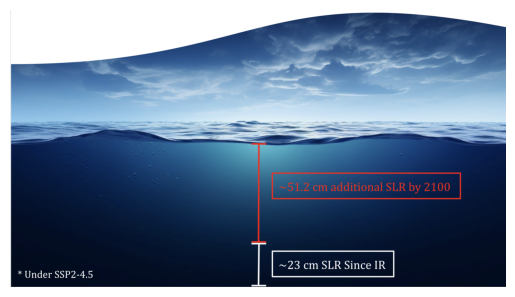

In [98]:
import matplotlib.image as mpimg
image = mpimg.imread("./SSP2-4.5_SLR_DV.png")
plt.imshow(image)
plt.axis("off")
plt.show()

Bar Plot of Sea Level Rise (Weighted Global Mean) and Total Cost for different SSPs

In [61]:
# Global Mean (Weighted) Sea Level Rise

# Latitude weights
weights_ssp126 = np.cos(np.deg2rad(ssp126_slr.lat))
weights_ssp245 = np.cos(np.deg2rad(ssp245_slr.lat))
weights_ssp370 = np.cos(np.deg2rad(ssp370_slr.lat))
weights_ssp585 = np.cos(np.deg2rad(ssp585_slr.lat))
# Normalize weights
weights_ssp126 = weights_ssp126 / weights_ssp126.mean()
weights_ssp245 = weights_ssp245 / weights_ssp245.mean()
weights_ssp370 = weights_ssp370 / weights_ssp370.mean()
weights_ssp585 = weights_ssp585 / weights_ssp585.mean()
# Global mean sea level rise
global_mean_ssp126 = float(ssp126_slr.weighted(weights_ssp126).mean(("lat", "lon")))
global_mean_ssp245 = float(ssp245_slr.weighted(weights_ssp245).mean(("lat", "lon")))
global_mean_ssp370 = float(ssp370_slr.weighted(weights_ssp370).mean(("lat", "lon")))
global_mean_ssp585 = float(ssp585_slr.weighted(weights_ssp585).mean(("lat", "lon")))

In [58]:
# Total Costs * Based on Protect10 Scenario
# Total Economic Cost SSP1-2.6
cost_ssp126 = (
    ds.costs.isel(case=1, scenario=0, ssp=0, iam=0, quantile=0)
    .sum(dim=["year", "costtype", "adm1"])
)
total_cost_ssp126 = float(cost_ssp126.compute())
# Total Economic Cost SSP2-4.5
cost_ssp245 = (
    ds.costs.isel(case=1, scenario=1, ssp=1, iam=0, quantile=0)
    .sum(dim=["year", "costtype", "adm1"])
)
total_cost_ssp245 = float(cost_ssp245.compute())
# Total Economic Cost SSP3-7.0
cost_ssp370 = (
    ds.costs.isel(case=1, scenario=2, ssp=2, iam=0, quantile=0)
    .sum(dim=["year", "costtype", "adm1"])
)
total_cost_ssp370 = float(cost_ssp370.compute())
# Total Economic Cost SSP5-8.5
cost_ssp585 = (
    ds.costs.isel(case=1, scenario=3, ssp=4, iam=0, quantile=0)
    .sum(dim=["year", "costtype", "adm1"])
)
total_cost_ssp585 = float(cost_ssp585.compute())
# Print results
print(total_cost_ssp126, total_cost_ssp245, total_cost_ssp370, total_cost_ssp585)

270772924841984.0 280313439715328.0 279072009617408.0 324278285238272.0


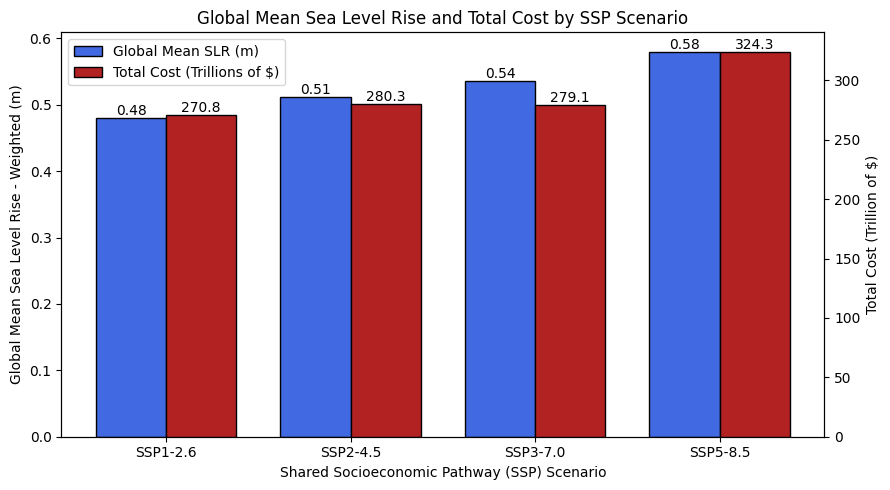

In [82]:
# Scenario labels
scenarios = ["SSP1-2.6", "SSP2-4.5", "SSP3-7.0", "SSP5-8.5"]
# Global Mean (Weighted) Sea Level Rise
slr_vals = [global_mean_ssp126, global_mean_ssp245, global_mean_ssp370, global_mean_ssp585]
# Costs in Trillions of Dollars
cost_vals = [float(total_cost_ssp126) / 1e12, float(total_cost_ssp245) / 1e12, 
             float(total_cost_ssp370) / 1e12, float(total_cost_ssp585) / 1e12]

# Plot Specifications
x = np.arange(len(scenarios))
width = 0.38
fig, ax1 = plt.subplots(figsize=(9, 5))

# Left axis: sea level rise (BLUE)
bars1 = ax1.bar(
    x - width/2,
    slr_vals,
    width,
    label="Global Mean SLR (m)",
    color="royalblue",
    edgecolor="black",
    linewidth=1
)

ax1.set_ylabel("Global Mean Sea Level Rise - Weighted (m)")
ax1.set_xticks(x)
ax1.set_xticklabels(scenarios)
ax1.set_title("Global Mean Sea Level Rise and Total Cost by SSP Scenario")

# Right axis: costs (RED)
ax2 = ax1.twinx()
bars2 = ax2.bar(
    x + width/2,
    cost_vals,
    width,
    label="Total Cost (Trillions of $)",
    color="firebrick",
    edgecolor="black",
    linewidth=1
)

# Axis Labels
ax2.set_ylabel("Total Cost (Trillion of $)")
ax1.set_xlabel("Shared Socioeconomic Pathway (SSP) Scenario")

# Add value labels
for bar in bars1:
    h = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        h,
        f"{h:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

for bar in bars2:
    h = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        h,
        f"{h:.1f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Combined legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper left")

#Plot
plt.tight_layout()
plt.show()

Cloropleth Graph SLR (SSP2-4.5)

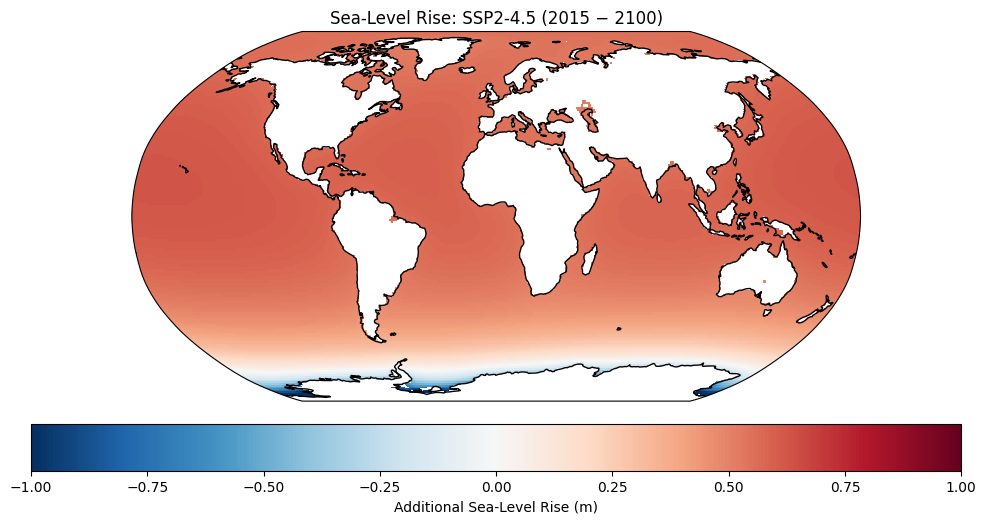

In [86]:
# # Obtain Latitude and Longitudinal Values
# lon, lat = ssp245_ds["lon"].values, ssp245_ds["lat"].values
# longitude, latitude = np.meshgrid(lon, lat)

# #Plot Specifications
# fig = plt.figure(figsize=(12, 6))
# ax = plt.axes(projection=ccrs.Robinson())
# pcm = ax.pcolormesh(
#     longitude,
#     latitude,
#     ssp245_slr.values,
#     transform=ccrs.PlateCarree(),
#     cmap="RdBu_r",
#     vmin=-1,
#     vmax=1
# )

# # Labels
# ax.coastlines()
# ax.set_title("Sea-Level Rise: SSP2-4.5 (2015 − 2100)")
# cbar = plt.colorbar(pcm, orientation="horizontal", pad=0.05)
# cbar.set_label("Additional Sea-Level Rise (m)")

# # Plot
# plt.show()